<a href="https://colab.research.google.com/github/DanielRojas1920/IAPIA-DanielRojas/blob/Modeltrain/JupyterNotebooks/XRay_ModelExample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Chest X-Ray YOLO Model Training Example**

This notebook is an example demonstrating how to load and explore the Chest X-ray dataset used for training a Deep Learning model. The dataset comprises 112,120 frontal-view X-ray images from 30,805 unique patients. Each image may have multi-label annotations for the following fourteen thoracic pathologies:

- Atelectasis
- Consolidation
- Infiltration
- Pneumothorax
- Edema
- Emphysema
- Fibrosis
- Effusion
- Pneumonia
- Pleural Thickening
- Cardiomegaly
- Nodule
- Mass
- Hernia

The focus of this notebook is solely on data loading and preliminary exploration.

# Installation of the requiered Libraries

If you're using Google Colab, just run the next cell. If you're using a local notebook (e.g., inside of VSC), change the cell language mode to Batch or similar.

In [1]:
!pip install huggingface_hub pandas keras

# Run parameters

Importing the libraries needed

In [2]:
import pandas as pd
import os
import zipfile
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm
from glob import glob
from itertools import chain
from matplotlib import pyplot as plt
import torch

Setting up the global variables

In [3]:
HUGGING_FACE = "hugging_face"
GOOGLE_DRIVE = "google_drive"

# Modify this variable to change the dataset download mode
DATASET_DOWNLOAD_MODE = HUGGING_FACE

# Modify this variable to specify the number of zip files downloaded (12 is the max num)
NUMBER_OF_IMAGE_ZIPS_TO_DOWNLOAD_FROM_DATASET = 12


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Clean environment

In [4]:
!rm -rf sample_data
# !rm -rf datasets/data

# Getting the dataset

You can either use the complete dataset (more than 40 GB will be needed) or a 17 GB dataset created from the original that is stored on Google Drive and can be mounted in order to load it quickly.

**Important**: The download size of the complete dataset is around 40 GB.

In [5]:
if DATASET_DOWNLOAD_MODE == HUGGING_FACE:
    from huggingface_hub import hf_hub_download

    REPO_ID = "alkzar90/NIH-Chest-X-ray-dataset"
    FILEPATH = "data/Data_Entry_2017_v2020.csv"

    datasets_path = Path("datasets/").mkdir(exist_ok=True)
    dataset_path = Path(hf_hub_download(repo_id=REPO_ID, filename=FILEPATH, repo_type="dataset", local_dir="datasets/"))

    # Download images
    for i in range(1, NUMBER_OF_IMAGE_ZIPS_TO_DOWNLOAD_FROM_DATASET+1):
        FILEPATH = f"data/images/images_{i:03d}.zip"
        downloaded_tmp_file = Path("datasets/") / "tmp" / f"zip-{i}-downloaded.tmp"

        if downloaded_tmp_file.exists():
            print(f"{FILEPATH} already exists. Skipping download.")
        else:
            print(f"Downloading {FILEPATH}...")
            zip_path = Path(hf_hub_download(
                repo_id=REPO_ID, filename=FILEPATH, repo_type="dataset", local_dir="datasets/"))

            # Create a temp file that indicates the zip was completely downloaded
            downloaded_tmp_file.mkdir(parents=True, exist_ok=True)
            downloaded_tmp_file.touch()

        extracted_tmp_file = Path("datasets/") / "tmp" / f"zip-{i}-extracted.tmp"
        if extracted_tmp_file.exists():
            print(f"{FILEPATH} already exists. Skipping download.")
        else:
            zipfile.ZipFile(zip_path).extractall("datasets/data/")

            # Create a temp file that indicates the zip was completely extracted
            extracted_tmp_file.mkdir(parents=True, exist_ok=True)
            extracted_tmp_file.touch()

            os.system(f"rm datasets/{FILEPATH}")

            print("ZIP extracted and removed!")

    print("Dataset downloaded and extracted!")

# TODO: Implement Google Drive mount
# elif DATASET_DOWNLOAD_MODE == GOOGLE_DRIVE:
#     from google.colab import drive
#     drive.mount('/content/drive')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


data/images/images_001.zip already exists. Skipping download.
data/images/images_001.zip already exists. Skipping download.
data/images/images_002.zip already exists. Skipping download.
data/images/images_002.zip already exists. Skipping download.
data/images/images_003.zip already exists. Skipping download.
data/images/images_003.zip already exists. Skipping download.
data/images/images_004.zip already exists. Skipping download.
data/images/images_004.zip already exists. Skipping download.
data/images/images_005.zip already exists. Skipping download.
data/images/images_005.zip already exists. Skipping download.
data/images/images_006.zip already exists. Skipping download.
data/images/images_006.zip already exists. Skipping download.
data/images/images_007.zip already exists. Skipping download.
data/images/images_007.zip already exists. Skipping download.
data/images/images_008.zip already exists. Skipping download.
data/images/images_008.zip already exists. Skipping download.
data/ima

# Data Exploration

Basic information of the Dataset is showed on the next cells

In [6]:
!ls datasets/data/images

Se truncaron las últimas líneas 5000 del resultado de transmisión.
00006086_000.png  00012904_005.png  00019407_010.png  00028897_014.png
00006086_001.png  00012904_006.png  00019407_011.png  00028897_015.png
00006086_002.png  00012904_007.png  00019408_000.png  00028897_016.png
00006087_000.png  00012904_008.png  00019409_000.png  00028897_017.png
00006088_000.png  00012905_000.png  00019410_000.png  00028897_018.png
00006089_000.png  00012905_001.png  00019411_000.png  00028897_019.png
00006090_000.png  00012905_002.png  00019412_000.png  00028897_020.png
00006090_001.png  00012905_003.png  00019413_000.png  00028898_000.png
00006091_000.png  00012905_004.png  00019413_001.png  00028899_000.png
00006091_001.png  00012905_005.png  00019414_000.png  00028899_001.png
00006092_000.png  00012905_006.png  00019415_000.png  00028899_002.png
00006093_000.png  00012906_000.png  00019415_001.png  00028900_000.png
00006094_000.png  00012907_000.png  00019415_002.png  00028901_000.png
00006095_0

## Describe()
Descriptive statistics of the numerical columns (by default)

In [7]:
csv_exploration = pd.read_csv(dataset_path)

csv_exploration.describe()

,Follow-up #,Patient ID,Patient Age,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
count,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000,112120.000000
mean,8.573751,14346.381743,46.626365,2646.078844,2486.438842,0.155649,0.155649
std,15.406320,8403.876972,16.602680,341.246429,401.268227,0.016174,0.016174
min,0.000000,1.000000,0.000000,1143.000000,966.000000,0.115000,0.115000
25%,0.000000,7310.750000,34.000000,2500.000000,2048.000000,0.143000,0.143000
50%,3.000000,13993.000000,49.000000,2518.000000,2544.000000,0.143000,0.143000
75%,10.000000,20673.000000,59.000000,2992.000000,2991.000000,0.168000,0.168000
max,183.000000,30805.000000,95.000000,3827.000000,4715.000000,0.198800,0.198800


 ## Head()
 First 5 rows of the DataFrame

In [8]:
csv_exploration.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
0,00000001_000.png,Cardiomegaly,0,1,57,M,PA,2682,2749,0.143,0.143
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168
3,00000002_000.png,No Finding,0,2,80,M,PA,2500,2048,0.171,0.171
4,00000003_001.png,Hernia,0,3,74,F,PA,2500,2048,0.168,0.168


## Deseases Distribution
Ocurrence of each label (desease)

In [9]:
# Get all labels ['Label1', 'Label3', 'Label1', ...]
all_labels = list(chain(*csv_exploration['Finding Labels'].map(lambda x: x.split('|')).tolist()))
# Get unique {'Label1', 'Label2', 'Label3', ...}
all_labels = list(set(all_labels))

# Add each label as a column and set 1 if the label was assigned to the image;
# otherwise, set 0.
for label in all_labels:
    csv_exploration[label] = csv_exploration['Finding Labels'].map(lambda finding_labels: 1 if label in finding_labels else 0)

print(
    '{} Labels\n{}'.format(
      len(all_labels),
      "\n".join([f"{label}: {int(csv_exploration[label].sum())}" for label in all_labels]),
    )
)

15 Labels
Consolidation: 4667
Nodule: 6331
Pneumothorax: 5302
Mass: 5782
Pleural_Thickening: 3385
Pneumonia: 1431
Fibrosis: 1686
Cardiomegaly: 2776
Hernia: 227
Infiltration: 19894
Edema: 2303
Emphysema: 2516
No Finding: 60361
Atelectasis: 11559
Effusion: 13317


Plot the Data

Text(0.5, 1.0, 'Occurrence of each desease')

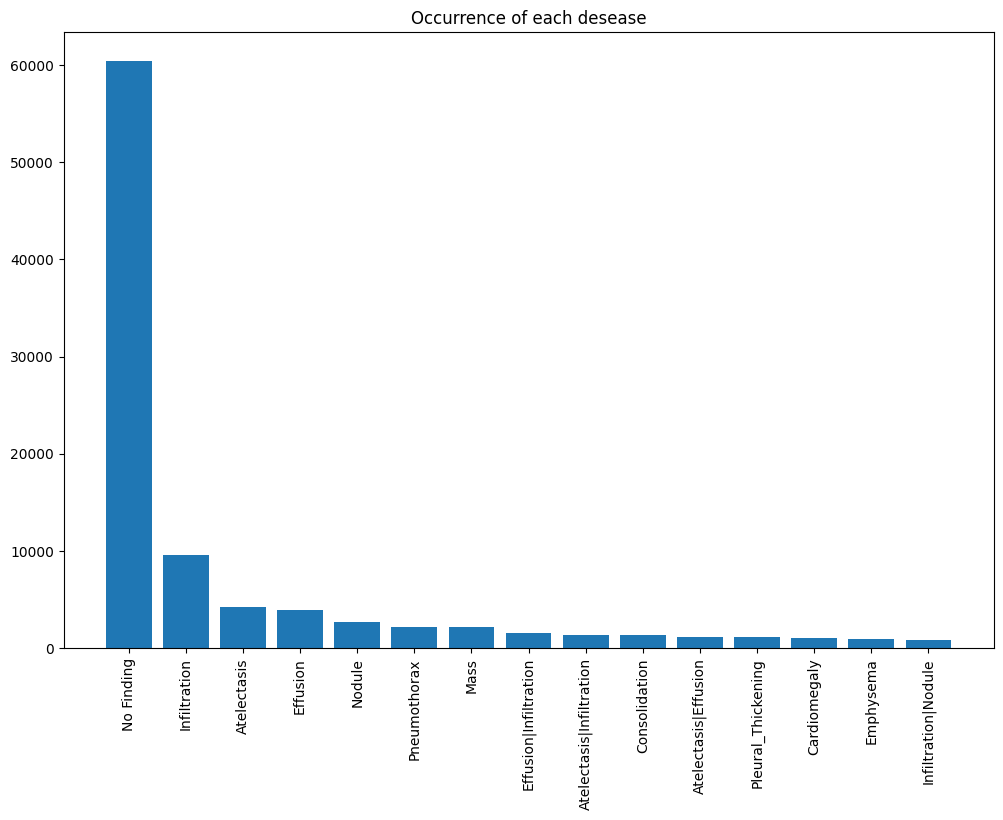

In [10]:
label_counts = csv_exploration['Finding Labels'].value_counts()[:15]

fig, ax1 = plt.subplots(1,1,figsize = (12, 8))

ax1.bar(np.arange(len(label_counts)) + 0.5, label_counts)

ax1.set_xticks(np.arange(len(label_counts)) + 0.5)

_ = ax1.set_xticklabels(label_counts.index, rotation = 90)

ax1.set_title("Occurrence of each desease")

## Information of the patients
### Age
Age distribution of the patients

In [11]:
csv_exploration['Patient Age'] = pd.to_numeric(csv_exploration['Patient Age'], errors='coerce')

unique_patients = csv_exploration.drop_duplicates(subset='Patient ID')

ages = unique_patients['Patient Age'].dropna()

ages.value_counts().sort_index()

,count
Patient Age,
0,14
1,39
2,42
3,60
4,78
...,...
90,4
91,2
92,2


Plot the Data

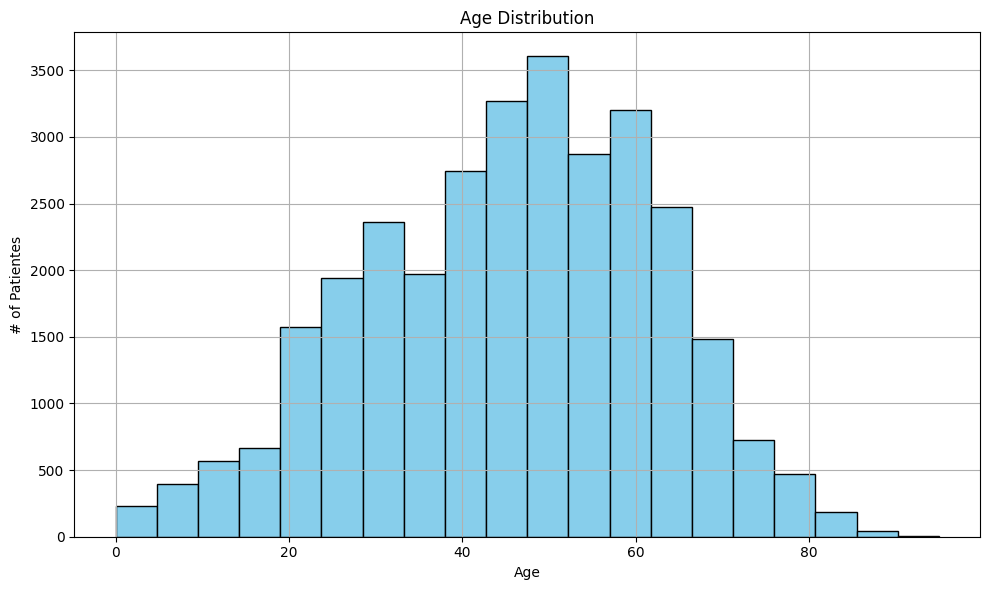

In [12]:
plt.figure(figsize=(10, 6))
plt.hist(ages, bins=20, edgecolor='black', color='skyblue')

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('# of Patientes')
plt.grid(True)
plt.tight_layout()
plt.show()

## Gender
Gender Global Distribution

In [13]:
gender_counts = unique_patients['Patient Gender'].value_counts()

gender_counts

,count
Patient Gender,
M,16630
F,14175


Plot the Data

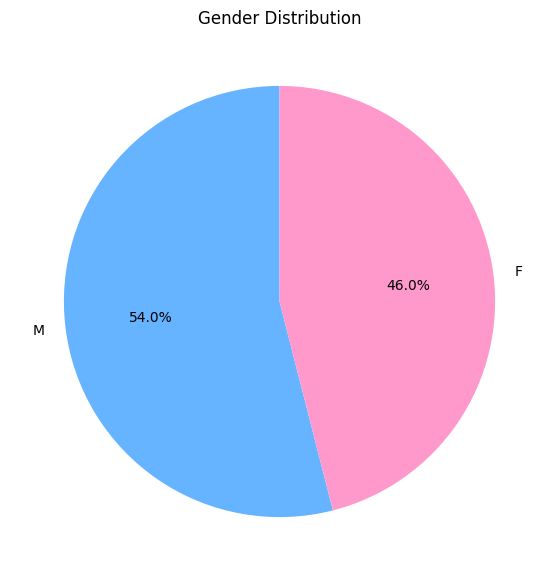

In [14]:
plt.figure(figsize=(7, 7))
gender_counts.plot(kind='pie', autopct='%1.1f%%', colors=['#66b3ff', '#ff99cc'], startangle=90, legend=False)


plt.title('Gender Distribution')

plt.ylabel('')
plt.show()

## Images Example
Showing the images stored on the dataset

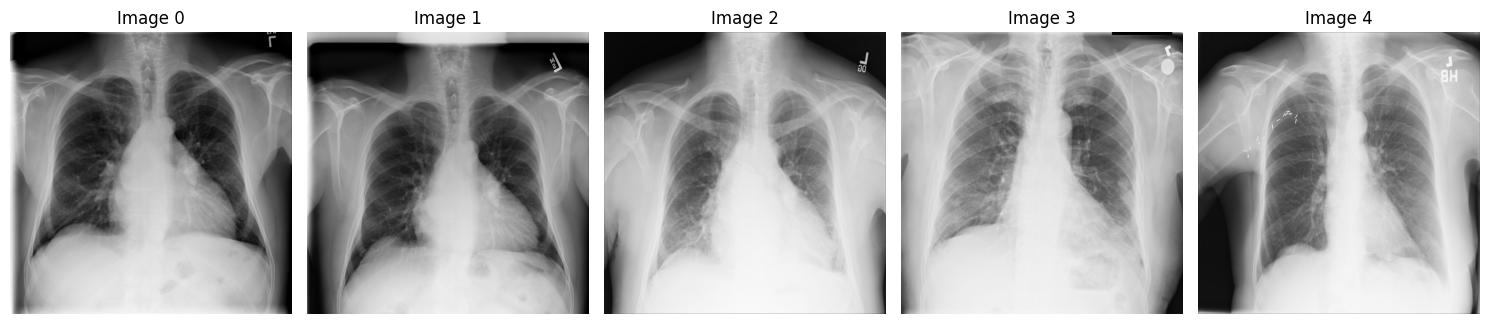

In [15]:
import cv2
import matplotlib.pyplot as plt
import os
from glob import glob


# Add an image_path column to the DataFrame
images_paths = {
    os.path.basename(x): x for x in
        glob(os.path.join('.', 'datasets', 'data', 'images', '*.png'))
}

csv_exploration['image_path'] = csv_exploration['Image Index'].map(images_paths.get)

plt.figure(figsize=(15, 5))

for i in range (0,5):
    img = cv2.imread(csv_exploration["image_path"].iloc[i])
    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.title(f"Image {i}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Data Preprocessing

The following section is destinated to Preprocess the data

## Removing Null Data
First, a CSV file is loaded that contains information related to a set of images. This information may include file names, labels, or any other relevant data for analysis.

Then, the project folders are searched to find all available images. Once located, a mapping is created between each image name and its exact location in the system.

With that information, a new column is added to the dataset, indicating the full path of each image. This allows the CSV data to be directly linked to the actual files on disk.

After that, all rows that do not have a corresponding image are removed. This way, the final dataset only includes complete examples that are ready to be used for analysis or model training.

In [16]:
csv = pd.read_csv(dataset_path)

# Add an image_path column to the DataFrame
images_paths = {
    os.path.basename(x): x for x in
        glob(os.path.join('.', 'datasets', 'data', 'images', '*.png'))
}

print(f'Found {len(images_paths)} images. Total Rows: {csv.shape[0]}')
csv['image_path'] = csv['Image Index'].map(images_paths.get)

# Remove rows that have a null path
csv.dropna(subset=['image_path'], inplace=True)
print(f"Dropped rows with a null path. {csv.shape[0]} rows remain.")

Found 112120 images. Total Rows: 112120
Dropped rows with a null path. 112120 rows remain.


## Labels Maping
First, the label information is cleaned by removing any indication that an image shows no findings, since this doesn’t provide useful information for the model. After this cleaning, all labels that appear in the dataset are extracted, regardless of how many times they occur.

Once the complete list is obtained, it is filtered to keep only the unique labels. This helps clearly identify all possible categories that could appear in an image.

Then, to make it easier for the model to work with, the label data is converted into a more structured format. For each label, a new column is created that contains a 1 if that category is present in the image, or a 0 if it is not. This way, each image is represented by a series of indicators summarizing its characteristics.

Finally, a few examples of the result are displayed, along with a brief summary of how often each label appears. This helps provide a general understanding of the type of data available and how it's distributed.

In [17]:
# Remove 'No Finding' labels from the Finding Labels column
csv['Finding Labels'] = csv['Finding Labels'].map(lambda x: x.replace('No Finding', ''))

# Get all labels ['Label1', 'Label3', 'Label1', ...]
all_labels = list(chain(*csv['Finding Labels'].map(lambda x: x.split('|')).tolist()))
# Get unique {'Label1', 'Label2', 'Label3', ...}
all_labels = list(set(all_labels))
# Remove empty string label
all_labels.remove('')

# Add each label as a column and set 1 if the label was assigned to the image;
# otherwise, set 0.
for label in all_labels:
    csv[label] = csv['Finding Labels'].map(lambda finding_labels: 1 if label in finding_labels else 0)

csv.sample(3)

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,...,Pleural_Thickening,Pneumonia,Fibrosis,Cardiomegaly,Hernia,Infiltration,Edema,Emphysema,Atelectasis,Effusion
104600,00027997_000.png,,0,27997,60,M,PA,2992,2991,0.143,...,0,0,0,0,0,0,0,0,0,0
74304,00018251_004.png,Atelectasis|Effusion|Infiltration,4,18251,5,M,AP,2048,2500,0.168,...,0,0,0,0,0,1,0,0,1,1
36071,00009520_003.png,,3,9520,48,M,PA,2500,2048,0.168,...,0,0,0,0,0,0,0,0,0,0


## Resampling the highly unbalanced dataset
This step addresses a common issue in many medical datasets: class imbalance. Specifically, there are many more images of healthy patients or those with common conditions, compared to those with multiple or rare diseases. If a model is trained directly on this data, it will tend to focus only on the most frequent cases and overlook the less represented ones.

To mitigate this problem, a weight is calculated for each row in the dataset. This weight is based on the number of labels (medical findings) each image has. The more labels an image has, the higher its weight. This is based on the assumption that images with multiple conditions are less frequent and should therefore be sampled more often to balance the dataset.

Weight is `0.04 + number of findings` for each label.

Additionally, a small constant is added to each weight to ensure that even images with few or no labels still have a minimum chance of being selected. After all the weights are calculated, they are normalized to form a valid probability distribution.

Finally, a random sample is taken from half of the original dataset, using these weights as the sampling criterion. The result is a more balanced subset of data that preserves the diversity of medical conditions and improves the quality of model training.

### Distribution before resampling
The original Distribution is on the previous cells on Deseases Distribution

### Resampling Process

In [18]:
sample_weights = csv['Finding Labels'].map(
    lambda x: len(x.split('|')) if len(x)>0 else 0
).values + 4e-2
sample_weights /= sample_weights.sum()

# # If you want to see the weight of each row:
# for index, weight in enumerate(sample_weights):
#   print(f"Row {index}| Weight: {weight}")
# print(f"Length of sample weights: {len(sample_weights)}")
# print(f"Number of rows in dataset: {csv.shape[0]}")

sampled_df = csv.sample(csv.shape[0] // 2, weights=sample_weights)

### Distribution after resampling

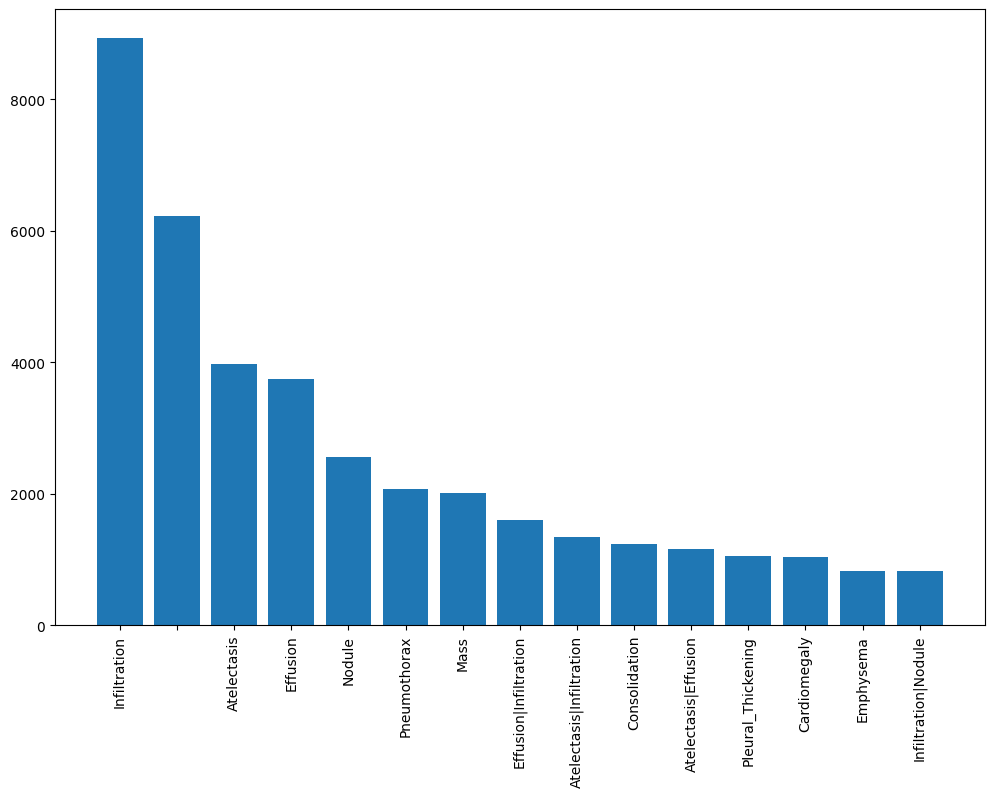

In [19]:
label_counts = sampled_df['Finding Labels'].value_counts()[:15]
fig, ax1 = plt.subplots(1,1,figsize = (12, 8))
ax1.bar(np.arange(len(label_counts)) + 0.5, label_counts)
ax1.set_xticks(np.arange(len(label_counts)) + 0.5)
_ = ax1.set_xticklabels(label_counts.index, rotation = 90)

### Delete images that are not in the dataframe returned from sampling
After selecting a balanced sample from the original dataset, a cleanup step is performed to remove images that are no longer needed. Specifically, images that were in the original DataFrame but were not included in the selected sample are identified.

Once identified, these images are physically deleted from the disk. This helps reduce the storage space used by files that are no longer useful for model training. The list of images to be deleted is processed, and if the file exists, it is removed from the file system.

In [20]:
# Get images from the original dataframe that are not sampled
images_to_delete = csv[~csv["image_path"].isin(sampled_df["image_path"])]["image_path"].values

# Delete images
'''for image_path in tqdm(images_to_delete):
    if os.path.isfile(image_path):
        os.remove(image_path)'''

'for image_path in tqdm(images_to_delete):\n    if os.path.isfile(image_path):\n        os.remove(image_path)'

## Create a column containing the diseases as a list
Once the sampled and balanced dataset is obtained, a new column called "disease_vec" is created. This column contains a binary vector for each image, representing the presence or absence of each possible medical label.

To construct this vector, the values of all the columns corresponding to the labels (i.e., the ones that were previously generated with 1s and 0s for each finding) are taken and grouped into an array. This way, each row has a vector that summarizes all the diseases associated with the image, in a format that is directly useful for training multi-label classification models.


In [21]:
sampled_df['disease_vec'] = sampled_df.apply(lambda x: x[all_labels].astype(int).values, axis=1)

sampled_df["disease_vec"]

,disease_vec
58810,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0]"
87262,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]"
56037,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]"
77530,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]"
78766,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
...,...
1942,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]"
48402,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
2400,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
45086,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"


## Gender
Changing the value of the column "Patient Age" to the following format:

Male = 0

Female = 1

Is more convenient for the model have the data on this format

In [22]:
sampled_df["Patient Gender"] = sampled_df.apply(lambda x: 0 if x["Patient Gender"] == 'M' else 1, axis=1)

sampled_df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,...,Pneumonia,Fibrosis,Cardiomegaly,Hernia,Infiltration,Edema,Emphysema,Atelectasis,Effusion,disease_vec
58810,00014555_000.png,Cardiomegaly|Edema,0,14555,56,0,AP,2500,2048,0.168,...,0,0,1,0,0,1,0,0,0,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0]"
87262,00021549_000.png,Infiltration,0,21549,45,1,PA,3056,2544,0.139,...,0,0,0,0,1,0,0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]"
56037,00013993_093.png,Consolidation|Effusion,93,13993,42,0,AP,2500,2048,0.168,...,0,0,0,0,0,0,0,0,1,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]"
77530,00019056_006.png,Infiltration|Nodule,6,19056,50,0,AP,3052,2544,0.139,...,0,0,0,0,1,0,0,0,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]"
78766,00019328_011.png,Nodule,11,19328,78,1,AP,3056,2544,0.139,...,0,0,0,0,0,0,0,0,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"


# View Position
Changing the value of the column "View Potition" to the following format:

PA = 0

AP = 1

Is more convenient for the model have the data on this format

In [23]:
sampled_df["View Position"] = sampled_df.apply(lambda x: 0 if x["View Position"] == 'PA' else 1, axis=1)

sampled_df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,...,Pneumonia,Fibrosis,Cardiomegaly,Hernia,Infiltration,Edema,Emphysema,Atelectasis,Effusion,disease_vec
58810,00014555_000.png,Cardiomegaly|Edema,0,14555,56,0,1,2500,2048,0.168,...,0,0,1,0,0,1,0,0,0,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0]"
87262,00021549_000.png,Infiltration,0,21549,45,1,0,3056,2544,0.139,...,0,0,0,0,1,0,0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]"
56037,00013993_093.png,Consolidation|Effusion,93,13993,42,0,1,2500,2048,0.168,...,0,0,0,0,0,0,0,0,1,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]"
77530,00019056_006.png,Infiltration|Nodule,6,19056,50,0,1,3052,2544,0.139,...,0,0,0,0,1,0,0,0,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]"
78766,00019328_011.png,Nodule,11,19328,78,1,1,3056,2544,0.139,...,0,0,0,0,0,0,0,0,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"


## Transform this features as a List


In [24]:
sampled_df["patient_info"] = sampled_df[["Patient Age", "Patient Gender", "View Position"]].values.tolist()

sampled_df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,...,Fibrosis,Cardiomegaly,Hernia,Infiltration,Edema,Emphysema,Atelectasis,Effusion,disease_vec,patient_info
58810,00014555_000.png,Cardiomegaly|Edema,0,14555,56,0,1,2500,2048,0.168,...,0,1,0,0,1,0,0,0,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0]","[56, 0, 1]"
87262,00021549_000.png,Infiltration,0,21549,45,1,0,3056,2544,0.139,...,0,0,0,1,0,0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]","[45, 1, 0]"
56037,00013993_093.png,Consolidation|Effusion,93,13993,42,0,1,2500,2048,0.168,...,0,0,0,0,0,0,0,1,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]","[42, 0, 1]"
77530,00019056_006.png,Infiltration|Nodule,6,19056,50,0,1,3052,2544,0.139,...,0,0,0,1,0,0,0,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]","[50, 0, 1]"
78766,00019328_011.png,Nodule,11,19328,78,1,1,3056,2544,0.139,...,0,0,0,0,0,0,0,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[78, 1, 1]"


## Split the dataset
At this stage, the balanced dataset is divided into three subsets: training, validation, and test.

First, 15% of the total dataset is separated as the test set (test_df). This portion is reserved for evaluating the final model once training is complete. To maintain a similar distribution of labels in each partition, the stratify option is used, which groups the samples based on the first few letters of the diagnostic labels. This helps ensure that the class proportions are not distorted too much in the test subset.

Then, the remaining 85% is further divided: 10% of this new group is allocated to the validation set (validation_df), which is used during the training process to tune hyperparameters and monitor overfitting. The rest is kept as the training set (train_df), which is used to actually learn the model's patterns.

Finally, the number of images in each subset is printed, allowing for a quick check to confirm that the splits were made correctly.

In [25]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(sampled_df,
                                   test_size = 0.15,
                                   random_state = 86196,
                                   stratify = sampled_df['Finding Labels'].map(lambda x: x[:4]))

train_df, validation_df = train_test_split(train_df,
                                   test_size = 0.10,
                                   random_state = 47941,
                                   stratify = train_df['Finding Labels'].map(lambda x: x[:4]))

print('Train:', train_df.shape[0], 'Validation:', validation_df.shape[0], 'Test:', test_df.shape[0])

Train: 42885 Validation: 4766 Test: 8409


## Data Argumentation

In this step, we create datasets and apply data augmentations to improve model generalization. The augmentations include:

- Converting images to tensors with normalized pixel values.
- Random cropping (using 90% of the original image size) to add variation.
- Resizing to a fixed size of 640x640 for consistency.
- Random affine transformations (rotation and translation) to simulate different viewing angles (which are present in the original images).
- Applying Gaussian blur to mimic imaging noise.

In [26]:
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2 as transforms
from PIL import Image
import cv2

IMAGE_SIZE = (640, 640)
ORIGINAL_IMAGE_SIZE = np.array(cv2.imread(train_df["image_path"].iloc[0]).shape[:2])
CROP_IMAGE_SIZE = (ORIGINAL_IMAGE_SIZE * 0.9).astype(int)

transform = transforms.Compose([
    transforms.ToTensor(), # image values will be scaled between 0 and 1
    transforms.RandomCrop(size=CROP_IMAGE_SIZE),
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomAffine(degrees=12, translate=(0.075, 0.075)),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.5, 1.5)),
])

class ChestXRayDataset(Dataset):
    def __init__(self, dataframe, path_column, patient_info, y_column, transform=None):
        self.dataframe = dataframe
        self.path_column = path_column
        self.patient_info = patient_info
        self.y_column = y_column
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        # Get the image path and label for the given index
        image_path = self.dataframe.iloc[index][self.path_column]
        label = self.dataframe.iloc[index][self.y_column]
        # Open image using PIL
        image = Image.open(image_path).convert("RGB")
        # Apply transformations
        if self.transform:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.float32)

        if self.patient_info:
            tabular_data = torch.tensor(self.dataframe.iloc[index][self.patient_info], dtype=torch.float32)
        else:
            tabular_data = torch.zeros(3, dtype=torch.float32)

        return image, tabular_data, label

/usr/local/lib/python3.11/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


## Get Final Dataset
A function is defined that takes a DataFrame, key columns, and batch size as input. This function uses the ChestXRayDataset class to create a dataset and then wraps it in a DataLoader, which handles delivering the data in batches with multiple processes in parallel to improve efficiency.

Three different datasets are created: one for training, one for validation, and one for testing. Each is configured with a different batch size. While they all use the same transformations in this example, a note is included to remind that ideally, the validation and test sets should not apply data augmentation, as they should reflect real data without alterations.

In [27]:
def get_images_dataset_from_dataframe(dataframe: pd.DataFrame,
                                      path_column: str, patient_info: str, y_column: str,
                                      batch_size: int) -> DataLoader:
    dataset = ChestXRayDataset(dataframe, path_column, patient_info, y_column, transform=transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    return loader

train_dataset = get_images_dataset_from_dataframe(
    dataframe=train_df,
    path_column="image_path",
    patient_info="patient_info",
    y_column="disease_vec",
    batch_size=96,
)

# TODO: Both validation and test datasets shouldn't be augmented
validation_dataset = get_images_dataset_from_dataframe(
    dataframe=validation_df,
    path_column="image_path",
    patient_info="patient_info",
    y_column="disease_vec",
    batch_size=96,
)
test_dataset = get_images_dataset_from_dataframe(
    dataframe=test_df,
    path_column="image_path",
    patient_info="patient_info",
    y_column="disease_vec",
    batch_size=96,
)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


## Save Preprocessed Data
Finally, the work done is saved to avoid repeating the entire preprocessing process in future sessions. Two folders are created: one to store the DataLoader objects as .pkl files, and another to save the splits of the DataFrame as .csv files.

Additionally, since the environment is Google Colab, a step is included to automatically download the CSV files to the user's local machine. This allows for easily preserving the dataset splits and reusing them without having to process the data from scratch again.

In [28]:
import pickle
from pathlib import Path

# Save DataLoader objects as pickle files
SAVED_DATASETS_DIR = Path("saved_datasets")
SAVED_DATASETS_DIR.mkdir(parents=True, exist_ok=True)

with open(SAVED_DATASETS_DIR / "train_dataset.pkl", "wb") as f:
    pickle.dump(train_dataset, f)
with open(SAVED_DATASETS_DIR / "validation_dataset.pkl", "wb") as f:
    pickle.dump(validation_dataset, f)
with open(SAVED_DATASETS_DIR / "test_dataset.pkl", "wb") as f:
    pickle.dump(test_dataset, f)

# Save dataframe splits as CSV files
SAVED_DATAFRAMES_DIR = Path("saved_dataframes")
SAVED_DATAFRAMES_DIR.mkdir(parents=True, exist_ok=True)

train_df.to_csv(SAVED_DATAFRAMES_DIR / "train_df.csv", index=False)
validation_df.to_csv(SAVED_DATAFRAMES_DIR / "validation_df.csv", index=False)
test_df.to_csv(SAVED_DATAFRAMES_DIR / "test_df.csv", index=False)

# Save the complete sampled dataframe
sampled_df.to_csv(SAVED_DATAFRAMES_DIR / "sampled_df.csv", index=False)

'''from google.colab import files
files.download(SAVED_DATAFRAMES_DIR / "train_df.csv")
files.download(SAVED_DATAFRAMES_DIR / "validation_df.csv")
files.download(SAVED_DATAFRAMES_DIR / "test_df.csv")
files.download(SAVED_DATAFRAMES_DIR / "sampled_df.csv")'''

'from google.colab import files\nfiles.download(SAVED_DATAFRAMES_DIR / "train_df.csv")\nfiles.download(SAVED_DATAFRAMES_DIR / "validation_df.csv")\nfiles.download(SAVED_DATAFRAMES_DIR / "test_df.csv")\nfiles.download(SAVED_DATAFRAMES_DIR / "sampled_df.csv")'

## Visualize the images from the datasets

In [29]:
'''NUM_BATCHES_TO_SHOW = 1

for index, (images, labels, patient_info) in enumerate(train_dataset):
    if index >= NUM_BATCHES_TO_SHOW:
        break
    print(f"*** BATCH {index+1} ***")
    for img, label in zip(images, labels):
        # Convert the one-hot label tensor to a list
        label = label.tolist()

        # Get all the Finding Labels corresponding to this image using one-hot encoding.
        finding_labels = [all_labels[i] for i, l in enumerate(label) if l == 1]
        if len(finding_labels) == 0:
            finding_labels = ["Healthy"]

        # Convert image tensor (C, H, W) to (H, W, C) for plotting and scale to 0-255 for visualization
        img_np = (img.permute(1, 2, 0).numpy() * 255).astype("uint8")

        plt.figure(figsize=(5,5))
        plt.imshow(img_np)
        plt.title(", ".join(finding_labels))
        plt.colorbar()
        plt.show()

    print("----------------------------------------------------------------\n" * 10)'''

'NUM_BATCHES_TO_SHOW = 1\n\nfor index, (images, labels, patient_info) in enumerate(train_dataset):\n    if index >= NUM_BATCHES_TO_SHOW:\n        break\n    print(f"*** BATCH {index+1} ***")\n    for img, label in zip(images, labels):\n        # Convert the one-hot label tensor to a list\n        label = label.tolist()\n\n        # Get all the Finding Labels corresponding to this image using one-hot encoding.\n        finding_labels = [all_labels[i] for i, l in enumerate(label) if l == 1]\n        if len(finding_labels) == 0:\n            finding_labels = ["Healthy"]\n\n        # Convert image tensor (C, H, W) to (H, W, C) for plotting and scale to 0-255 for visualization\n        img_np = (img.permute(1, 2, 0).numpy() * 255).astype("uint8")\n\n        plt.figure(figsize=(5,5))\n        plt.imshow(img_np)\n        plt.title(", ".join(finding_labels))\n        plt.colorbar()\n        plt.show()\n\n    print("----------------------------------------------------------------\n" * 10)'

# Model Train

## Create and train the fine-tuned model (option 1)

### Download the base model

In [30]:
def create_model_dirs():
    current_dir = Path.cwd()

    subdirs = [current_dir / name for name in ("saved_models",)]

    for subdir in subdirs:
        if not subdir.is_dir():
            print(f"Directory '{subdir}' not found. Creating it...")
            subdir.mkdir(parents=True)
            print(f"Created!")

    load_model_path.parent.mkdir(parents=True, exist_ok=True)

def download_model():
    from urllib.request import urlretrieve
    import zipfile
    import os
    from time import sleep

    url = "https://www.dropbox.com/scl/fi/jvgh2zh0nh0uc306ay3nc/yolo11m-seg.pt?rlkey=9ouh5cawxdf9qcdggpms30mc3&st=x54c05m2&dl=1"

    # download model from Dropbox
    try:
        urlretrieve(url, "saved_models/yolo11m-seg/model.pt")
    except Exception as e:
        print(f"Exception occurred: {e}.")
        if (Path.is_file(load_model_path)):
            print("Deleting partially downloaded file...")
            os.remove(load_model_path)

def setup():
    create_model_dirs()

    if not load_model_path.exists():
        print("Model not found. Downloading it...")
        download_model()
        print("Downloaded!")

def remove_setup():
    import shutil
    if model_base_dir.exists():
        shutil.rmtree(model_base_dir)
        print(f"Removed directory: {model_base_dir}")
    else:
        print(f"Directory {model_base_dir} does not exist. Nothing to remove.")

model_base_dir = Path.cwd() / "saved_models" / "yolo11m-seg"
load_model_path = model_base_dir / "model.pt"

# Uncomment to restart the setup
remove_setup()

setup()

Removed directory: /content/saved_models/yolo11m-seg
Model not found. Downloading it...
Downloaded!


### Load the base model

In [31]:
from torch import load as torch_load, serialization

#to Avoid the error: "Could not load symbol cudnnGetLibConfig. Error: /usr/local/lib/python3.11/dist-packages/torch/lib/../../nvidia/cudnn/lib/libcudnn_graph.so.9: undefined symbol: cudnnGetLibConfig"
#1-Install Ultralytics
#2-Comment the Line "!pip install ultralytics"
#3-Restart the session

#!pip install ultralytics

model = torch_load(load_model_path, weights_only=False)



In [32]:
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

### Train base model on the NIH Chest X-Ray dataset

In [33]:
import torch
import torch.nn as nn
from torch.utils.data import Subset, DataLoader

# Wrapper model that combines image-based features and tabular data for classification
class ClassificationWrapper(nn.Module):
    def __init__(self, segmentation_model, num_classes=14, tabular_dim=3):
        super().__init__()
        self.segmentation_model = segmentation_model
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))  # Reduces spatial dimensions to 1x1
        self.tabular_data = tabular_dim

        # Linear layer to project image features from 144 to 64 dimensions
        self.image_fc = nn.Linear(144, 64)

        # Linear layer to project tabular features to 32 dimensions
        self.tabular_fc = nn.Linear(tabular_dim, 32)

        # Final classification layers after combining image and tabular features
        self.combined_fc = nn.Sequential(
            nn.ReLU(),
            nn.Linear(64 + 32, num_classes)  # Combine both modalities for final prediction
        )

    def forward(self, x_image, x_tabular):
        outputs = self.segmentation_model(x_image)

        # TODO: Fix this part. When .eval() is used, the model throws an exception
        if isinstance(outputs, (list, tuple)):
            out = outputs[0]  # Take first multi-scale output
            out = out[0]      # First channel (grayscale image)
        else:
            out = outputs

        pooled = self.avgpool(out)  # Output shape: [B, 144, 1, 1]
        pooled = pooled.view(pooled.size(0), -1)  # Flatten to [B, 144]
        image_feat = self.image_fc(pooled)        # Transform image features: [B, 64]
        tabular_feat = self.tabular_fc(x_tabular) # Transform tabular data: [B, 32]

        combined = torch.cat((image_feat, tabular_feat), dim=1)  # Concatenate: [B, 96]
        logits = self.combined_fc(combined)  # Final classification layer: [B, num_classes]
        return logits


net = ClassificationWrapper(model['model']).to(device).float()

optimizer = torch.optim.Adam(net.parameters(), lr=1e-4)
criterion = nn.BCEWithLogitsLoss()

# Training loss decreases only during the first two epochs
# Additional epochs provide negligible improvement
num_epochs = 5

# Just for Quick Testing: sample subset of full training dataset, replace all the instances of train_dataset to train_loader
'''full_dataset = ChestXRayDataset(train_df, path_column="image_path", y_column="disease_vec", patient_info="patient_info", transform=transform)

sampled_train_dataset = Subset(full_dataset, range(100))

train_loader = DataLoader(sampled_train_dataset, batch_size=16, shuffle=True)'''


for epoch in range(num_epochs):
    net.train()
    running_loss = 0.0
    for i, (images, tabular_data, labels) in enumerate(train_dataset):  # <- fixed tuple unpacking
        images = images.to(device)
        tabular_data = tabular_data.to(device)  # <- move tabular input to device

        labels = labels.to(device).float()  # multilabel targets as floats

        optimizer.zero_grad()
        outputs = net(images, tabular_data)  # <- pass both image and tabular input If you get an error about out of memory, try restarting the session, 96 for batch size was the max value tested (but sometime crashes)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if (i + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_dataset)}], Loss: {loss.item():.4f}")
    print(f"Epoch [{epoch+1}/{num_epochs}] Average Loss: {running_loss/len(train_dataset):.4f}")

fine_tuned_model = net


Epoch [1/5], Step [10/447], Loss: 1.0701
Epoch [1/5], Step [20/447], Loss: 0.7956
Epoch [1/5], Step [30/447], Loss: 0.6182
Epoch [1/5], Step [40/447], Loss: 0.4822
Epoch [1/5], Step [50/447], Loss: 0.4090
Epoch [1/5], Step [60/447], Loss: 0.3695
Epoch [1/5], Step [70/447], Loss: 0.3283
Epoch [1/5], Step [80/447], Loss: 0.3255
Epoch [1/5], Step [90/447], Loss: 0.3004
Epoch [1/5], Step [100/447], Loss: 0.3244
Epoch [1/5], Step [110/447], Loss: 0.3022
Epoch [1/5], Step [120/447], Loss: 0.3134
Epoch [1/5], Step [130/447], Loss: 0.2954
Epoch [1/5], Step [140/447], Loss: 0.3062
Epoch [1/5], Step [150/447], Loss: 0.3098
Epoch [1/5], Step [160/447], Loss: 0.2943
Epoch [1/5], Step [170/447], Loss: 0.3083
Epoch [1/5], Step [180/447], Loss: 0.3046
Epoch [1/5], Step [190/447], Loss: 0.3038
Epoch [1/5], Step [200/447], Loss: 0.3151
Epoch [1/5], Step [210/447], Loss: 0.3070
Epoch [1/5], Step [220/447], Loss: 0.3569
Epoch [1/5], Step [230/447], Loss: 0.3048
Epoch [1/5], Step [240/447], Loss: 0.2839
E

### Save the Model Trained

In [34]:
# Save the complete model
torch.save(net, model_base_dir / "model_classification_architecture.pt")
# Save the model state
torch.save(net.state_dict(), model_base_dir / "model_classification.pt")
# Save the model optimizer state
torch.save(optimizer.state_dict(), model_base_dir / "optimizer_classification.pt")
# Save the model training state
torch.save({"epoch": num_epochs, "loss": loss}, model_base_dir / "training_state_classification.pt")

In [35]:
# print(outputs[0].shape, "\n", outputs[1].shape, "\n", outputs[2].shape)
# print(labels.shape)
images.shape
# print(net)
# print(out.shape) # must make the out variable in forward() global

torch.Size([69, 3, 640, 640])

## Loss Graph

In [ ]:
#TODO

## Validation Graph

In [ ]:
#TODO

### Download the trained model

In [36]:
from google.colab import files
files.download('/content/saved_models/yolo11m-seg/model_classification.pt')
files.download('/content/saved_models/yolo11m-seg/model_classification_architecture.pt')
files.download('/content/saved_models/yolo11m-seg/optimizer_classification.pt')
files.download('/content/saved_models/yolo11m-seg/training_state_classification.pt')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Use the fine-tuned model from Dropbox (option 2)

### Download the fine-tuned model

In [37]:
'''def create_model_dirs():
    current_dir = Path.cwd()

    subdirs = [current_dir / name for name in ("fine-tuned_models",)]

    for subdir in subdirs:
        if not subdir.is_dir():
            print(f"Directory '{subdir}' not found. Creating it...")
            subdir.mkdir(parents=True)
            print(f"Created!")

    load_model_path.parent.mkdir(parents=True, exist_ok=True)

def download_model():
    from urllib.request import urlretrieve
    import zipfile
    import os
    from time import sleep

    url = "https://www.dropbox.com/scl/fi/5c4m39bcq2x331xk03rho/model.pt?rlkey=dugi45dnd9mud32ie131rxxfv&st=9sa3rtg6&dl=1"

    # download model from Dropbox
    try:
        urlretrieve(url, "fine-tuned_models/yolo11m-seg/model.pt")
    except Exception as e:
        print(f"Exception occurred: {e}.")
        if (Path.is_file(load_model_path)):
            print("Deleting partially downloaded file...")
            os.remove(load_model_path)

def setup():
    create_model_dirs()

    if not load_model_path.exists():
        print("Model not found. Downloading it...")
        download_model()
        print("Downloaded!")

def remove_setup():
    import shutil
    if model_base_dir.exists():
        shutil.rmtree(model_base_dir)
        print(f"Removed directory: {model_base_dir}")
    else:
        print(f"Directory {model_base_dir} does not exist. Nothing to remove.")

model_base_dir = Path.cwd() / "fine-tuned_models" / "yolo11m-seg"
load_model_path = model_base_dir / "model.pt"

# Uncomment to restart the setup
remove_setup()

setup()'''

'def create_model_dirs():\n    current_dir = Path.cwd()\n\n    subdirs = [current_dir / name for name in ("fine-tuned_models",)]\n\n    for subdir in subdirs:\n        if not subdir.is_dir():\n            print(f"Directory \'{subdir}\' not found. Creating it...")\n            subdir.mkdir(parents=True)\n            print(f"Created!")\n\n    load_model_path.parent.mkdir(parents=True, exist_ok=True)\n\ndef download_model():\n    from urllib.request import urlretrieve\n    import zipfile\n    import os\n    from time import sleep\n\n    url = "https://www.dropbox.com/scl/fi/5c4m39bcq2x331xk03rho/model.pt?rlkey=dugi45dnd9mud32ie131rxxfv&st=9sa3rtg6&dl=1"\n\n    # download model from Dropbox\n    try:\n        urlretrieve(url, "fine-tuned_models/yolo11m-seg/model.pt")\n    except Exception as e:\n        print(f"Exception occurred: {e}.")\n        if (Path.is_file(load_model_path)):\n            print("Deleting partially downloaded file...")\n            os.remove(load_model_path)\n\ndef se

## Load the fine-tuned model

In [38]:
'''from torch import load as torch_load, serialization
!pip install ultralytics

fine_tuned_model = torch_load(load_model_path, weights_only=False, map_location=torch.device(device))'''

'from torch import load as torch_load, serialization\n!pip install ultralytics\n\nfine_tuned_model = torch_load(load_model_path, weights_only=False, map_location=torch.device(device))'

# Analyze and visualize the model

In [39]:
from torch.utils.tensorboard import SummaryWriter
import torchvision

In [40]:
original_model_logs = Path("runs/logs/original_model")
original_model_logs.mkdir(parents=True, exist_ok=True)

# WARNING: Delete every log inside the directory
for log in original_model_logs.glob("*"):
    log.unlink()

In [42]:
import datetime
now = datetime.datetime.now()
now_str = now.strftime("%d_%m_%Y-%H_%M_%S")

# Create a SummaryWriter to log TensorBoard events into the "runs" directory.
writer = SummaryWriter(original_model_logs, filename_suffix=now_str)

# Log the model graph
input_example = next(iter(train_dataset))[0][0].unsqueeze(0).to(device).float()

original_net = model["model"].to(device).float()
original_net.eval()

writer.add_graph(original_net, input_example)

# Log dataset information as text.
dataset_info = (
    f"Train dataset size: {len(train_dataset.dataset)}\n"
    f"Validation dataset size: {len(validation_dataset.dataset)}\n"
    f"Test dataset size: {len(test_dataset.dataset)}"
)
writer.add_text("Dataset Info", dataset_info, global_step=0)

# Log a grid of sample images from the train dataset.
images,tabular_data, _ = next(iter(train_dataset))
#images, _ = next(iter(train_dataset))
img_grid = torchvision.utils.make_grid(images)
writer.add_image("Train Images", img_grid, global_step=0)

# Log histograms for model weights (for one epoch: step 0).
for name, param in model["model"].named_parameters():
    writer.add_histogram(name, param, global_step=0)

writer.close()

print(f"TensorBoard logs are saved in the '{original_model_logs}' directory.")

TensorBoard logs are saved in the 'runs/logs/original_model' directory.


In [ ]:
# Load the TensorBoard notebook extension
%load_ext tensorboard
# Run TensorBoard
%tensorboard --logdir runs/logs/original_model

# Inference

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Probability of each label
Consolidation: 0.0622
Nodule: 0.1184
Pneumothorax: 0.0883
Mass: 0.1098
Pleural_Thickening: 0.0654
Pneumonia: 0.0260
Fibrosis: 0.0286
Cardiomegaly: 0.0485
Hernia: 0.0040
Infiltration: 0.2773
Edema: 0.0353
Emphysema: 0.0533
Atelectasis: 0.2072
Effusion: 0.2082
Predicted labels: ['Infiltration']
Actual labels: ['Mass']


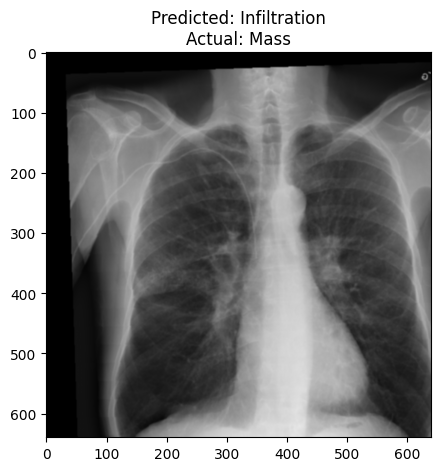

Probability of each label
Consolidation: 0.0672
Nodule: 0.1004
Pneumothorax: 0.0971
Mass: 0.0676
Pleural_Thickening: 0.0494
Pneumonia: 0.0342
Fibrosis: 0.0257
Cardiomegaly: 0.0511
Hernia: 0.0042
Infiltration: 0.3309
Edema: 0.0469
Emphysema: 0.0359
Atelectasis: 0.1620
Effusion: 0.1816
Predicted labels: ['Infiltration']
Actual labels: ['Mass']


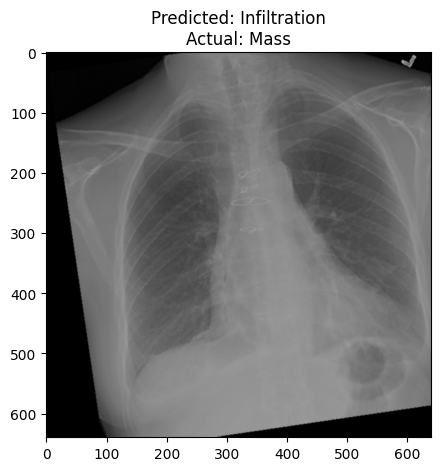

Probability of each label
Consolidation: 0.0771
Nodule: 0.0824
Pneumothorax: 0.1015
Mass: 0.0547
Pleural_Thickening: 0.0444
Pneumonia: 0.0374
Fibrosis: 0.0219
Cardiomegaly: 0.0530
Hernia: 0.0037
Infiltration: 0.3935
Edema: 0.0525
Emphysema: 0.0310
Atelectasis: 0.1451
Effusion: 0.1877
Predicted labels: ['Infiltration']
Actual labels: ['Mass']


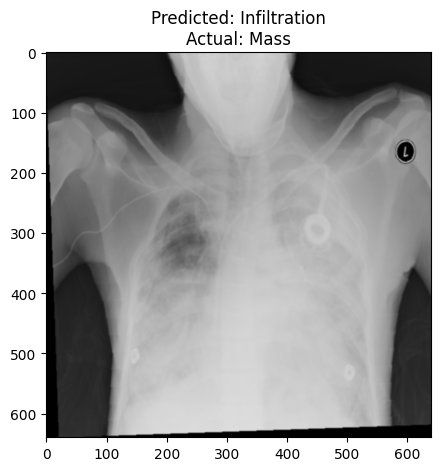

Probability of each label
Consolidation: 0.0754
Nodule: 0.0845
Pneumothorax: 0.0974
Mass: 0.0609
Pleural_Thickening: 0.0491
Pneumonia: 0.0292
Fibrosis: 0.0231
Cardiomegaly: 0.0525
Hernia: 0.0034
Infiltration: 0.3714
Edema: 0.0534
Emphysema: 0.0402
Atelectasis: 0.1671
Effusion: 0.2125
Predicted labels: ['Infiltration']
Actual labels: ['Mass']


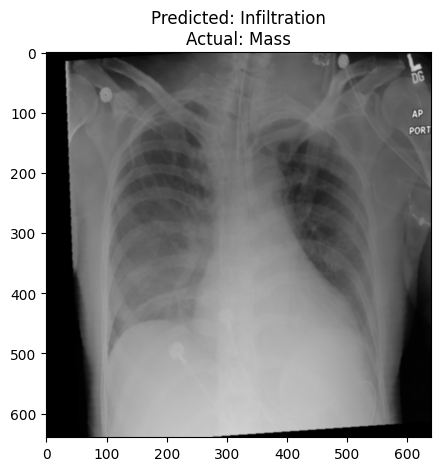

Probability of each label
Consolidation: 0.0703
Nodule: 0.0991
Pneumothorax: 0.0902
Mass: 0.0954
Pleural_Thickening: 0.0636
Pneumonia: 0.0232
Fibrosis: 0.0256
Cardiomegaly: 0.0504
Hernia: 0.0033
Infiltration: 0.3196
Edema: 0.0413
Emphysema: 0.0572
Atelectasis: 0.2076
Effusion: 0.2376
Predicted labels: ['Infiltration']
Actual labels: ['Mass']


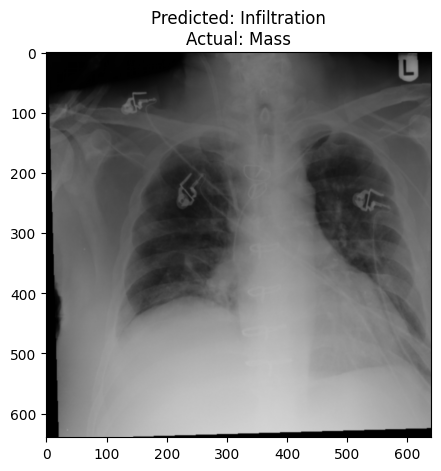

In [48]:
# Get the model inside the dictionary
fine_tuned_net = fine_tuned_model.to(device).float()

# # Set the network to evaluation mode

# with torch.no_grad():
#     # TODO: net.train() works fine, but with net.eval(),
#     # ValueError: Input dimension should be at least 3
#     # raises
#     for i, (images, labels) in enumerate(train_dataset):
#         images = images.to(device)
#         # show image 0
#         plt.imshow(images[0].permute(1, 2, 0).cpu().numpy())
#         plt.show()

#         # image = images[0]
#         # print(image.shape)

#         outputs = net(images)
#         print(outputs)

# TODO: net.train() works fine, but with net.eval(),
fine_tuned_net.train()

# Get a single batch from the validation dataset and use the first image for inference
with torch.no_grad():
    num_predictions = 0
    for images, tabular_data, label  in validation_dataset:
        # Select the first image and add a batch dimension
        image = images[0].unsqueeze(0).to(device)
        tabular = tabular_data[0].unsqueeze(0).to(device)

        # Do inference
        logits = fine_tuned_net(image, tabular)
        probs = torch.sigmoid(logits)

        print("Probability of each label")
        for label, prob in zip(all_labels, probs[0]):
            print(f"{label}: {prob.item():.4f}")

        # Apply a threshold to determine predicted labels
        pred_vector = (probs > 0.25).int().squeeze().tolist()
        if isinstance(pred_vector, int):
            pred_vector = [pred_vector]

        # Convert the predicted vector to corresponding disease names.
        predicted_labels = [all_labels[i] for i, flag in enumerate(pred_vector) if flag == 1]
        if not predicted_labels:
            predicted_labels = ["Healthy"]

        print("Predicted labels:", predicted_labels)

        # Ground truth
        actual_labels = [all_labels[i] for i, flag in enumerate(labels[0].tolist()) if flag == 1]
        if not actual_labels:
            actual_labels = ["Healthy"]

        print("Actual labels:", actual_labels)

        plt.figure(figsize=(5,5))
        plt.title(f"Predicted: {', '.join(predicted_labels)}\nActual: {', '.join(actual_labels)}")
        plt.imshow(images[0].permute(1, 2, 0).cpu().numpy())
        plt.show()

        num_predictions += 1

        if num_predictions >= 5:
            break

# What's next

* The model is currently predicting every image as Healthy with a threshold of 0.5. Maybe the 0.5 threshold is too high or there's something wrong in the training, causing the probability assigned to each class to be too low. Might also try implementing weighted losses.
* With a threshold of 0.25, the model predicts all images as Infiltration and Effusion. Might be a sign of imbalance. Weighted losses might help.
* The way the wrapper was made for the PyTorch model is a mess.
* The net should be in eval() mode.
* Implement a visualization of the segmentation made by the model on the images.
* Currently, it seems like the whole neural network is being trained instead of just the last layers. Instead of a fine-tuning, a complete retraining is being made. That might be why the 5 epochs took around 90 minutes using a Google Colab instance with a GPU. Only the last layers should be modified during the training and the rest should be freezed.